
# Pseudo-Voigt laser image mixer

This notebook uses the geometry constants from `make_laser_image.py` and a column-wise pseudo-Voigt fit to synthesize a laser image from two template images:

- `empty_template_img`: fitted column-wise and used where the local mask selects empty/no-filament behavior.
- `full_template_img`: fitted column-wise and used where the local mask selects full/filament behavior.

The input mask is a boolean array shaped `(w, l)` using the same unrotated rectangle constants as `make_laser_image.py`: `w = 80`, `l = 325`, starting at `(row=160, col=210)`, then rotated by `-(270 + 26.2)` around `(320, 240)`.


In [1]:

from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares

# Uploaded test image
TEST_IMAGE_PATH = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_162_t_5877.161994_x_202.514362_y_121.323688_z_0.108491.jpg")

# Constants copied from make_laser_image.py
RECT_ROW0 = 160      # x in that file, but it is used as a row index
RECT_COL0 = 210      # y in that file, but it is used as a col index
LASER_W = 80
LASER_L = 325
CANVAS_SHAPE = (640, 640)     # pre-rotation canvas, rows x cols
OUT_SIZE = (640, 480)         # cv2 warpAffine size, width x height
ROT_CENTER = (320, 240)       # x, y in OpenCV coordinates
ROT_ANGLE_DEG = -(270 + 26.2)


## Pseudo-Voigt fitting

In [2]:

def pseudo_voigt_profile(x, A, x0, sigma, gamma, p, B):
    """A * [p * Lorentz + (1-p) * Gaussian] + B. Both components peak at 1."""
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), 1e-6)
    gamma = max(float(gamma), 1e-6)
    gauss = np.exp(-0.5 * ((x - x0) / sigma) ** 2)
    lorentz = 1.0 / (1.0 + ((x - x0) / gamma) ** 2)
    return A * (p * lorentz + (1.0 - p) * gauss) + B


def pseudo_voigt_fit(x, y, p0=None, bounds=None, method='robust', robust_loss='huber', robust_f_scale=3.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    y_min, y_max = float(np.min(y)), float(np.max(y))
    A0 = max(y_max - y_min, 1e-6)
    x0_0 = float(x[np.argmax(y)])
    weights = np.maximum(y - y_min, 0)
    sigma0 = np.sqrt(np.sum((x - x0_0) ** 2 * weights) / (np.sum(weights) + 1e-12))
    sigma0 = max(float(sigma0), 1.0)
    p0 = [A0, x0_0, sigma0, max(1.0, sigma0 / 2), 0.5, y_min] if p0 is None else p0

    if bounds is None:
        span = float(x.max() - x.min())
        bounds = ([0, x.min(), 0.1, 0.1, 0, y_min - A0],
                  [np.inf, x.max(), 2 * span, 2 * span, 1, y_max + A0])

    lb, ub = np.asarray(bounds[0], float), np.asarray(bounds[1], float)
    p0 = np.clip(np.asarray(p0, float), lb, ub)

    try:
        if method == 'robust':
            resid = lambda params: pseudo_voigt_profile(x, *params) - y
            res = least_squares(resid, p0, bounds=(lb, ub), loss=robust_loss,
                                f_scale=robust_f_scale, max_nfev=20_000)
            popt, success, msg = res.x, bool(res.success), str(res.message)
            pcov = None
        elif method == 'lsq':
            popt, pcov = curve_fit(pseudo_voigt_profile, x, y, p0=p0,
                                   bounds=bounds, maxfev=20_000)
            success, msg = True, 'curve_fit converged'
        else:
            raise ValueError("method must be 'robust' or 'lsq'")
    except Exception as e:
        popt, pcov, success, msg = p0, None, False, f'fit failed: {e}'

    model = lambda xx: pseudo_voigt_profile(np.asarray(xx, dtype=float), *popt)
    sigma, gamma, p = popt[2], popt[3], popt[4]
    fwhm = p * (2 * gamma) + (1 - p) * (2 * np.sqrt(2 * np.log(2)) * sigma)
    return {'params': popt, 'param_cov': pcov, 'fwhm': float(fwhm),
            'model': model, 'residuals': y - model(x),
            'success': success, 'message': msg}


def fit_template_columns(img, method='robust', robust_loss='huber', robust_f_scale=3.0):
    """Fit one pseudo-Voigt profile per image column, along the row/y axis."""
    img = read_gray(img).astype(float)
    rows = np.arange(img.shape[0])
    params = np.zeros((img.shape[1], 6), dtype=float)
    success = np.zeros(img.shape[1], dtype=bool)

    p0 = None
    for c in range(img.shape[1]):
        res = pseudo_voigt_fit(rows, img[:, c], p0=p0, method=method,
                               robust_loss=robust_loss, robust_f_scale=robust_f_scale)
        params[c] = res['params']
        success[c] = res['success']
        p0 = params[c]  # previous column is usually the best initial guess

    return {'params': params, 'success': success, 'fit_img': eval_fit_image(params, img.shape)}


def eval_fit_image(params, shape):
    """Vectorized evaluation of all fitted column profiles into an image."""
    rows = np.arange(shape[0], dtype=float)[:, None]
    A, x0, sigma, gamma, p, B = [params[:, i][None, :] for i in range(6)]
    sigma = np.maximum(sigma, 1e-6)
    gamma = np.maximum(gamma, 1e-6)
    gauss = np.exp(-0.5 * ((rows - x0) / sigma) ** 2)
    lorentz = 1.0 / (1.0 + ((rows - x0) / gamma) ** 2)
    return A * (p * lorentz + (1.0 - p) * gauss) + B


## Laser-mask geometry and image mixing

In [3]:

def read_gray(img_or_path):
    if isinstance(img_or_path, (str, Path)):
        img = cv2.imread(str(img_or_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(img_or_path)
        return img
    img = np.asarray(img_or_path)
    if img.ndim == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()


def rotate_local_mask(local_mask_wl):
    """Place a local (w,l) mask into the unrotated rectangle, then rotate into image coords."""
    local_mask_wl = np.asarray(local_mask_wl, dtype=bool)
    if local_mask_wl.shape != (LASER_W, LASER_L):
        raise ValueError(f'local mask must have shape {(LASER_W, LASER_L)}, got {local_mask_wl.shape}')

    canvas = np.zeros(CANVAS_SHAPE, dtype=np.uint8)
    canvas[RECT_ROW0:RECT_ROW0 + LASER_W, RECT_COL0:RECT_COL0 + LASER_L] = local_mask_wl.astype(np.uint8)
    M = cv2.getRotationMatrix2D(ROT_CENTER, ROT_ANGLE_DEG, 1)
    return cv2.warpAffine(canvas, M, OUT_SIZE, flags=cv2.INTER_NEAREST).astype(bool)


def laser_roi_mask():
    return rotate_local_mask(np.ones((LASER_W, LASER_L), dtype=bool))


def make_laser_image(local_mask_wl, empty_template_img, full_template_img,
                     mask_true='empty', background='zeros', fit_cache=None,
                     return_debug=False):
    """
    Build a fitted laser image by selecting between empty/full column-wise fits.

    Parameters
    ----------
    local_mask_wl : bool ndarray, shape (LASER_W, LASER_L)
        Mask in the unrotated laser rectangle coordinates.
    empty_template_img, full_template_img : path or ndarray
        Images used to fit the empty/full pseudo-Voigt column profiles.
    mask_true : {'empty', 'full'}
        If 'empty', True pixels in local_mask_wl use the empty template fit.
        If 'full', True pixels in local_mask_wl use the full template fit.
    background : {'zeros', 'empty_template', 'empty_fit'} or ndarray
        What to put outside the rotated laser ROI.
    fit_cache : dict or None
        Optional cache so repeated calls do not refit the same templates.
    return_debug : bool
        If True, also return masks and fit objects.
    """
    empty = read_gray(empty_template_img).astype(float)
    full = read_gray(full_template_img).astype(float)
    if empty.shape != full.shape:
        raise ValueError(f'empty/full shapes differ: {empty.shape} vs {full.shape}')

    fit_cache = {} if fit_cache is None else fit_cache

    def get_fit(name, img):
        key = (name, img.shape, img.dtype.str, float(img.mean()), float(img.std()))
        if key not in fit_cache:
            fit_cache[key] = fit_template_columns(img)
        return fit_cache[key]

    empty_fit = get_fit('empty', empty)
    full_fit = empty_fit if np.array_equal(empty, full) else get_fit('full', full)

    roi = laser_roi_mask()
    choice = rotate_local_mask(local_mask_wl)
    if mask_true == 'full':
        use_full = choice
    elif mask_true == 'empty':
        use_full = ~choice
    else:
        raise ValueError("mask_true must be 'full' or 'empty'")
    use_full &= roi

    if background == 'zeros':
        out = np.zeros_like(empty, dtype=float)
    elif background == 'empty_template':
        out = empty.copy()
    elif background == 'empty_fit':
        out = empty_fit['fit_img'].copy()
    else:
        out = np.asarray(background, dtype=float).copy()
        if out.shape != empty.shape:
            raise ValueError('background ndarray must match template image shape')

    out[roi] = empty_fit['fit_img'][roi]
    out[use_full] = full_fit['fit_img'][use_full]
    out_u8 = np.clip(out, 0, 255).astype(np.uint8)

    if return_debug:
        return out_u8, {'laser_roi': roi, 'choice_mask': choice, 'use_full': use_full,
                        'empty_fit': empty_fit, 'full_fit': full_fit}
    return out_u8


## Test against the uploaded frame

In [4]:

# This smoke test uses the uploaded frame as both the empty and full template.
# That isolates whether the rotation constants + column fits reconstruct the frame's laser ROI.
# Replace these two paths with real empty/full templates when available.
empty_template = r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2419_t_6020.320204_x_193.516000_y_105.383861_z_1.086427.jpg"
full_template = r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2308_t_6013.260147_x_186.984561_y_140.439561_z_0.126997.jpg"

frame = read_gray(TEST_IMAGE_PATH)
all_full_mask = np.ones((LASER_W, LASER_L), dtype=bool)
cache = {}

made, dbg = make_laser_image(all_full_mask, empty_template, full_template,
                             mask_true='full', background='zeros',
                             fit_cache=cache, return_debug=True)

roi = dbg['laser_roi']
frame_roi = np.where(roi, frame, 0).astype(np.uint8)
diff = made.astype(float) - frame_roi.astype(float)

print('image shape:', frame.shape)
print('laser ROI pixels:', int(roi.sum()))
print('fit success rate:', dbg['full_fit']['success'].mean())
print('ROI MAE:', np.mean(np.abs(diff[roi])))
print('ROI RMSE:', np.sqrt(np.mean(diff[roi] ** 2)))


image shape: (480, 640)
laser ROI pixels: 25998
fit success rate: 0.9984375
ROI MAE: 15.657012077852142
ROI RMSE: 24.526847246727357


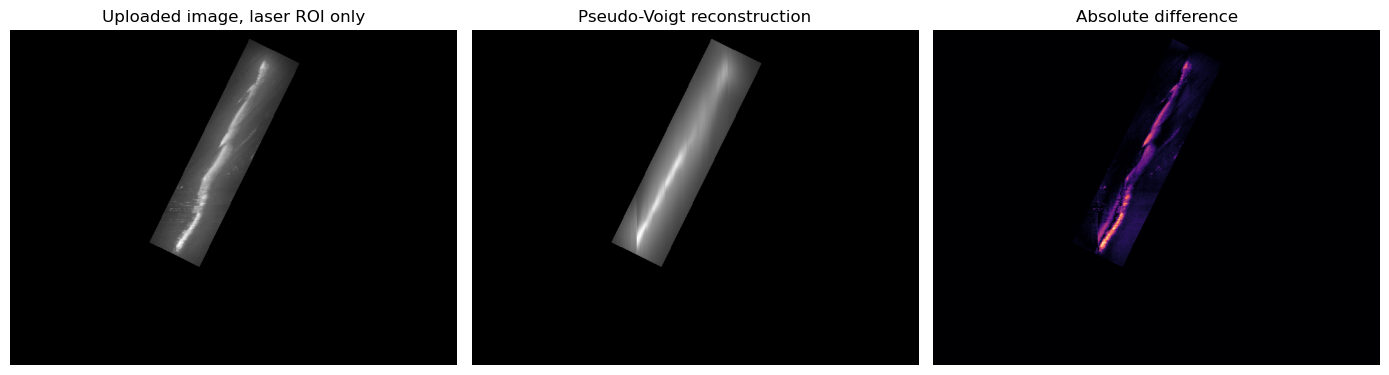

In [5]:

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.imshow(frame_roi, cmap='gray')
plt.title('Uploaded image, laser ROI only')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(made, cmap='gray')
plt.title('Pseudo-Voigt reconstruction')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(np.abs(diff), cmap='magma')
plt.title('Absolute difference')
plt.axis('off')
plt.tight_layout()
plt.show()


## Mixed-mask example

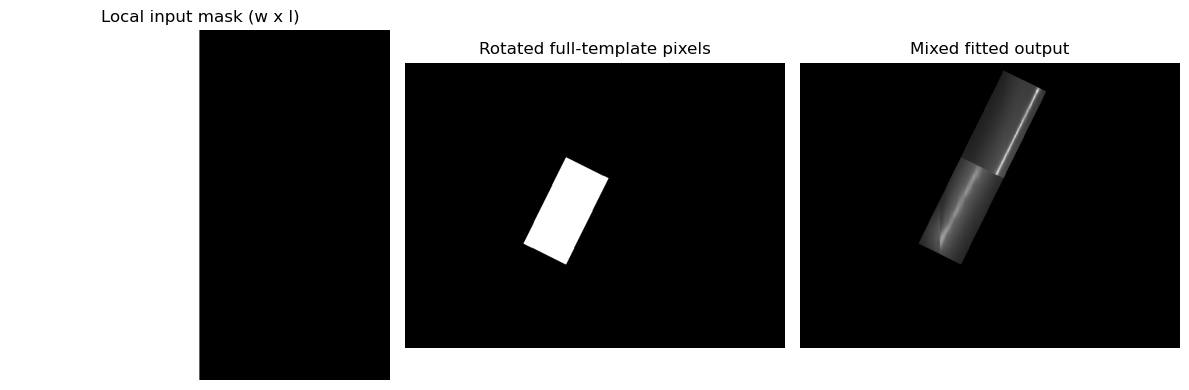

In [6]:

# Example local bool mask in unrotated (w,l) coordinates:
# This example uses mask_true='full', so True = full template fit and False = empty template fit.
# With real empty/full templates this will synthesize a half-full, half-empty laser rectangle.
half_mask = np.zeros((LASER_W, LASER_L), dtype=bool)
half_mask[:, :LASER_L // 2] = True

mixed, mixed_dbg = make_laser_image(half_mask, empty_template, full_template,
                                    mask_true='full', background='zeros',
                                    fit_cache=cache, return_debug=True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(half_mask, cmap='gray', aspect='auto')
plt.title('Local input mask (w x l)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mixed_dbg['use_full'], cmap='gray')
plt.title('Rotated full-template pixels')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mixed, cmap='gray')
plt.title('Mixed fitted output')
plt.axis('off')
plt.tight_layout()
plt.show()


## Column-fit sanity plot

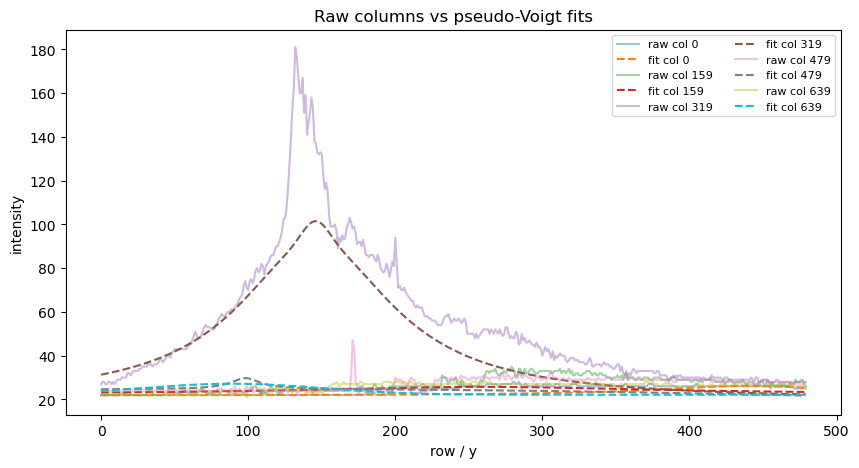

In [7]:

# Plot a few fitted columns over raw data.
cols = np.linspace(0, frame.shape[1] - 1, 5, dtype=int)
rows = np.arange(frame.shape[0])
fit_img = dbg['full_fit']['fit_img']

plt.figure(figsize=(10, 5))
for c in cols:
    plt.plot(rows, frame[:, c], alpha=0.45, label=f'raw col {c}')
    plt.plot(rows, fit_img[:, c], '--', label=f'fit col {c}')
plt.xlabel('row / y')
plt.ylabel('intensity')
plt.legend(ncol=2, fontsize=8)
plt.title('Raw columns vs pseudo-Voigt fits')
plt.show()
